In [1]:
import os
import pandas as pd
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jrandom
import equinox as eqx
import diffrax
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from  SepsisDataset import SepsisDataset

In [2]:
dataset = SepsisDataset()

  0%|          | 0/20001 [00:00<?, ?it/s]

In [3]:
class GRUODE(eqx.Module):
    vector_field: eqx.nn.MLP
    rnn_cell: eqx.nn.GRUCell
    linear_out: eqx.nn.Linear
    hidden_size: int

    def __init__(self, in_size, hidden_size, out_size, key):
        k1, k2, k3 = jrandom.split(key, 3)
        self.hidden_size = hidden_size
        self.vector_field = eqx.nn.MLP(in_size=hidden_size, out_size=hidden_size, width_size=hidden_size, depth=1, key=k1)
        self.rnn_cell = eqx.nn.GRUCell(in_size, hidden_size, key=k2)
        self.linear_out = eqx.nn.Linear(hidden_size, out_size, key=k3)

    def __call__(self, ts, obs):
        h0 = jnp.zeros((self.hidden_size,), dtype=obs.dtype)
        init_carry = (h0, ts[0])
        xs = (ts[1:], obs[1:])

        def vf(t, y, args):
            return jnp.tanh(self.vector_field(y))

        term = diffrax.ODETerm(vf)

        def scan_fn(carry, x):
            h_prev, t_prev = carry
            t_curr, obs_curr = x
            sol = diffrax.diffeqsolve(
                term,
                diffrax.Tsit5(),
                t0=t_prev,
                t1=t_curr,
                dt0=t_curr - t_prev,
                y0=h_prev
            )
            h_ode = jnp.squeeze(sol.ys, axis=0)
            h_next = self.rnn_cell(obs_curr, h_ode)
            return (h_next, t_curr), None

        (h_final, _), _ = jax.lax.scan(scan_fn, init_carry, xs)
        linear_out = self.linear_out(h_final)
        return jax.nn.sigmoid(linear_out)

In [5]:
BATCH_SIZE = 64
HIDDEN_SIZE = 16
LEARNING_RATE = 1e-3

key = jrandom.PRNGKey(567)
model = GRUODE(in_size=40, hidden_size=HIDDEN_SIZE, out_size=1, key=key)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(LEARNING_RATE)
)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

@eqx.filter_value_and_grad
def loss_fn(model, batch_ts, batch_obs, batch_y):
    # pred_y = jax.vmap(model)(batch_ts, batch_obs)
    pred_y = model(batch_ts, batch_obs)
    pred_y = pred_y.squeeze()
    return optax.sigmoid_binary_cross_entropy(pred_y, batch_y).mean()

@eqx.filter_jit
def make_step(model, opt_state, batch_ts, batch_obs, batch_y):
    loss, grads = loss_fn(model, batch_ts, batch_obs, batch_y)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

def test_loss(model):
    total_loss = 0.0
    count = 0
    for ts, obs, y in dataset.test:
        pred_y = model(ts, obs)
        pred_y = pred_y.squeeze()
        loss = optax.sigmoid_binary_cross_entropy(pred_y, y).mean()
        total_loss += loss.item()
        count += 1
    return total_loss / count if count > 0 else 0.0
        
loss_history = []

Epoch 1:   0%|          | 0/18000 [00:00<?, ?it/s]

Epoch 1 Average Loss: 0.6894


Epoch 2:   0%|          | 0/18000 [00:00<?, ?it/s]

Epoch 2 Average Loss: 0.6874


Epoch 3:   0%|          | 0/18000 [00:00<?, ?it/s]

Epoch 3 Average Loss: 0.6875


Epoch 4:   0%|          | 0/18000 [00:00<?, ?it/s]

Epoch 4 Average Loss: 0.6872


Epoch 5:   0%|          | 0/18000 [00:00<?, ?it/s]

Epoch 5 Average Loss: 0.6871


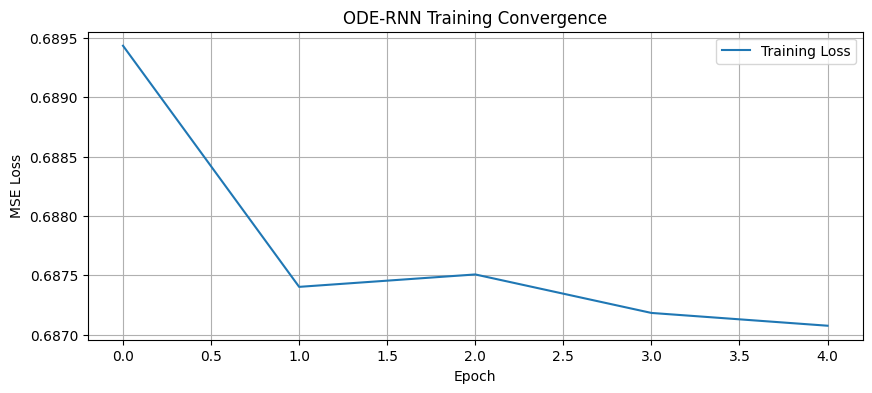

In [6]:
EPOCHS = 5
l_key = jrandom.PRNGKey(0)

for epoch in range(EPOCHS):
    epoch_loss = 0
    
    l_key, subkey = jrandom.split(l_key)
    
    # Add TQDM
    pbar = tqdm(iter(dataset.train), total=len(dataset.train), desc=f"Epoch {epoch+1}")
    
    for batch_ts, batch_obs, batch_y in pbar:
        model, opt_state, loss = make_step(model, opt_state, batch_ts, batch_obs, batch_y)
        loss_val = loss.item()
        epoch_loss += loss_val
        pbar.set_postfix(loss=loss_val)
            
    
    print(f"Epoch {epoch+1} Average Loss: {epoch_loss / len(dataset.train) :.4f}")
    loss_history.append(epoch_loss / len(dataset.train))
    
plt.figure(figsize=(10, 4))
plt.plot(loss_history, label='Training Loss')
plt.title("ODE-RNN Training Convergence")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
true_positives = 0
false_positives = 0
true_negatives = 0
false_negatives = 0

for ts, obs, y in dataset.test:
    pred_y = model(ts, obs)
    pred_label = (pred_y >= 0.5).astype(int)
    true_label = int(y)
    if pred_label == 1 and true_label == 1:
        true_positives += 1
    elif pred_label == 1 and true_label == 0:
        false_positives += 1
    elif pred_label == 0 and true_label == 0:
        true_negatives += 1
    elif pred_label == 0 and true_label == 1:
        false_negatives += 1
    
accuracy = (true_positives + true_negatives) / i
precision = true_positives / (true_positives + false_positives + 1e-8)
recall = true_positives / (true_positives + false_negatives + 1e-8)
f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

print("True Positives:", true_positives)
print("False Positives:", false_positives)
print("True Negatives:", true_negatives)
print("False Negatives:", false_negatives)



Accuracy: 18.9600
Precision: 0.8182
Recall: 0.2727
F1 Score: 0.4091
True Positives: 36
False Positives: 8
True Negatives: 1860
False Negatives: 96
